# Baselines and evaluation

## 1. Split and metrics
I split matches in time: train 2000-2021, validation 2022-2023, test from 2024. I only look at the test set once, at the end.
I score probabilities with log loss, Brier score and ranked probability score (RPS). Lower is better for all three.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np

from src.evaluation import OUTCOMES, compare
from src.splits import load_matches

matches = load_matches()
train = matches[matches["split"] == "train"]
valid = matches[matches["split"] == "valid"]
matches["split"].value_counts()

split
train    19490
test      2583
valid     1887
Name: count, dtype: int64

## 2. Naive baselines
I estimate outcome frequencies on the training set only, then apply them to the validation set.

In [2]:
freq_overall = train["result"].value_counts(normalize=True)[OUTCOMES].to_numpy()
freq_by_venue = train.groupby("neutral")["result"].value_counts(normalize=True).unstack()[OUTCOMES]

predictions = {
    "uniform": np.full((len(valid), 3), 1 / 3),
    "overall_frequency": np.tile(freq_overall, (len(valid), 1)),
    "frequency_by_venue": freq_by_venue.reindex(valid["neutral"]).to_numpy(),
}
compare(predictions, valid["result"])

,log_loss,brier,rps
uniform,1.0986,0.6667,0.2399
overall_frequency,1.0490,0.6324,0.2283
frequency_by_venue,1.0436,0.6283,0.2263


The uniform baseline gives a log loss of ln(3) = 1.0986, the floor any model must beat.
Using outcome frequencies by venue improves all three metrics: the model gives on average 35.2% to the actual outcome (exp(-1.0436)), against 33.3% for uniform. This is the score to beat.

## 3. Elo baseline
I turn the Elo gap into three probabilities with a multinomial logistic regression on two features: the Elo gap (per 100 points) and home venue.

In [6]:
from src.models.elo_logistic import EloLogistic
from src.plots import plot_calibration

elo_model = EloLogistic().fit(train)
predictions["elo_logistic"] = elo_model.predict_proba(valid)
compare(predictions, valid["result"])

,log_loss,brier,rps
uniform,1.0986,0.6667,0.2399
overall_frequency,1.0490,0.6324,0.2283
frequency_by_venue,1.0436,0.6283,0.2263
elo_logistic,0.8847,0.5197,0.1747


In [7]:
dict(zip(elo_model.model.classes_, elo_model.model.coef_.round(3).tolist()))

{'A': [-0.344, -0.401], 'D': [-0.007, 0.027], 'H': [0.351, 0.374]}

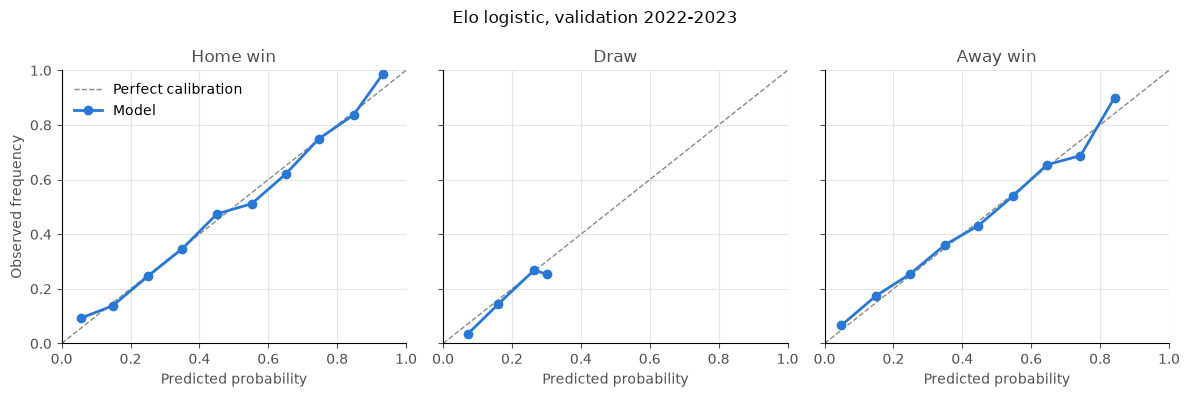

In [8]:
fig = plot_calibration(predictions["elo_logistic"], valid["result"], "Elo logistic, validation 2022-2023")
fig.savefig("../reports/figures/calibration_elo_valid.png", dpi=150, bbox_inches="tight")

The Elo logistic model cuts the log loss from 1.0436 to 0.8847: on average it gives 41.3% to the actual outcome, against 35.2% for frequencies by venue.
Playing at home is worth about 100 Elo points (97 against a draw, 111 against an away win), close to the +100 used in the Elo update.
Home and away wins are well calibrated. Draw probabilities never exceed 30%, as in the data, with slight overconfidence around 30%.
This is the baseline every model has to beat.